## 1 - ISOMAP shape analysis

| Situation | Action |
|---|---|
| 1 fragment | ISOMAP on all vertices |
| N fragments | ISOMAP on each fragment separately + fragmentation features |

Why per-fragment: geodesic distances between disconnected islands are infinite.
Running ISOMAP independently per fragment avoids a corrupted distance matrix.

Important: the ISOMAP axes are **arbitrary embedding coordinates**, not anatomical X/Y/Z axes.
A star-like or wing-like shape does **not** mean the scar literally has 3 Cartesian axes; it means
the 2-D embedding is unfolding the fragment geometry that way.

Colours identify fragment rank within each case: blue = largest fragment (F1), orange = second (F2),
green = third (F3), red = fourth (F4), etc. They do not encode anatomy.

Panel title convention: `(3f) [-18 tiny]` means 3 fragments were kept for analysis and 18 extra
tiny connected components were dropped by the `MIN_VERTS_FRAGMENT` filter.

Tiny disconnected islands are often segmentation noise rather than meaningful scar islands.
To reduce clutter, fragments with fewer than MIN_VERTS_FRAGMENT vertices are dropped before the
fragment count and ISOMAP plot are produced. Fragments with fewer than MIN_VERTS_ISOMAP vertices
are kept in the count but not embedded.

Future note: area-based filtering would be better than vertex-count filtering, but the current
vertex threshold is a practical first pass.

In [ ]:
import os, sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
from IPython.display import display
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

def _find_project_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src").exists():
            return path
        nested = path / "lv-scar-segmentation"
        if (nested / "src").exists():
            return nested
    raise RuntimeError(f"Could not find lv-scar-segmentation/src from {start}")

CWD = Path.cwd().resolve()
ROOT = _find_project_root(CWD)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import scan

HD_ROOT = Path(os.environ.get("LV_SCAR_DATA_ROOT", r"F:/RM_TEKNON_DEVELOP"))
CLINICAL_CSV = Path(os.environ.get(
    "LV_SCAR_CLINICAL_CSV",
    r"C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv",
))

SEED = 42
ISOMAP_PTS = 800
ISOMAP_K = 10
MIN_VERTS_FRAGMENT = 30
MIN_VERTS_ISOMAP = 5
MAX_PLOT_FRAGMENTS = 4

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
OUT = RESULTS / "M02_isomaps"
OUT.mkdir(parents=True, exist_ok=True)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120

def has_cz(case):
    path = case.tissue_surfaces.get("core")
    return path is not None and path.exists()

def _case_key(case):
    return f"{case.year}/{case.patient_id}"

def _best_shell(case):
    """Left Ventricle > Myocardium > Endo > Epi."""
    for key in ("lv", "myocardium", "endo", "epi"):
        path = case.anatomy.get(key)
        if path is not None and path.exists():
            return pv.read(str(path))
    return None

all_cases = scan(HD_ROOT)
valid = [case for case in all_cases if has_cz(case)]
known = list(valid)

print(f"Project root : {ROOT}")
print(f"Dataset root : {HD_ROOT}")
print(f"Valid CZ full cohort : {len(valid)}")
print(f"Analysed cases       : {len(known)}")
print(f"Output dir           : {OUT}")


In [ ]:
@dataclass
class CZAnalysis:
    key:                  str
    raw_n_fragments:      int
    n_fragments:          int
    dropped_fragments:    int
    vertex_counts:        list
    largest_fraction:     float
    centroids:            np.ndarray
    centroid_dist_matrix: np.ndarray
    fragment_meshes:      list
    embeddings:           list

    @property
    def is_compact(self):
        return self.n_fragments == 1


def _run_isomap(pts, k=ISOMAP_K, n_pts=ISOMAP_PTS):
    if len(pts) > n_pts:
        idx = np.random.default_rng(SEED).choice(len(pts), n_pts, replace=False)
        pts = pts[idx]
    k_actual = min(k, len(pts) - 1)
    return Isomap(n_neighbors=k_actual, n_components=2).fit_transform(pts)


def _normalise_embedding(emb):
    emb = np.asarray(emb, dtype=float)
    emb = emb - emb.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(emb, axis=1).max()
    if scale > 0:
        emb = emb / scale
    return emb


def _connected_fragments(mesh):
    """Return one cleaned surface mesh per connected scar fragment.

    connectivity() labels regions, but RegionId may live on cell data while
    mesh.points is point data. Threshold each region into its own sub-mesh
    to avoid point/cell indexing mismatches.
    """
    labeled = mesh.connectivity(largest=False)
    if 'RegionId' in labeled.cell_data:
        region_ids = np.unique(np.asarray(labeled.cell_data['RegionId']).astype(int))
    elif 'RegionId' in labeled.point_data:
        region_ids = np.unique(np.asarray(labeled.point_data['RegionId']).astype(int))
    else:
        return [mesh]

    fragments = []
    for rid in region_ids:
        piece = labeled.threshold((rid - 0.5, rid + 0.5), scalars='RegionId')
        piece = piece.extract_surface().clean()
        if piece.n_points > 0:
            fragments.append(piece)
    fragments.sort(key=lambda m: m.n_points, reverse=True)
    return fragments


def _filter_fragments(fragments, min_points=MIN_VERTS_FRAGMENT):
    kept = [frag for frag in fragments if frag.n_points >= min_points]
    if kept:
        return kept
    return fragments[:1]


def analyze_cz(case):
    key       = f"{case.year}/{case.patient_id}"
    cz        = pv.read(str(case.tissue_surfaces["core"]))
    fragments_all = _connected_fragments(cz)
    raw_n_frags   = len(fragments_all)
    fragments     = _filter_fragments(fragments_all)
    n_frags       = len(fragments)
    if n_frags == 0:
        raise ValueError('no connected scar fragments found')
    dropped_fragments = raw_n_frags - n_frags

    vertex_counts, centroids, embeddings = [], [], []
    for frag in fragments:
        pts = np.array(frag.points)
        vertex_counts.append(len(pts))
        centroids.append(pts.mean(axis=0))
        if len(pts) >= MIN_VERTS_ISOMAP:
            try:
                embeddings.append(_normalise_embedding(_run_isomap(pts)))
            except Exception as e:
                print(f"    ISOMAP failed {key}: {e}")
                embeddings.append(None)
        else:
            embeddings.append(None)
    centroids = np.array(centroids)
    dist_mat  = cdist(centroids, centroids) if len(centroids) > 1 else np.zeros((1, 1))
    return CZAnalysis(
        key=key, raw_n_fragments=raw_n_frags, n_fragments=n_frags,
        dropped_fragments=dropped_fragments,
        vertex_counts=vertex_counts,
        largest_fraction=vertex_counts[0] / max(sum(vertex_counts), 1),
        centroids=centroids, centroid_dist_matrix=dist_mat,
        fragment_meshes=fragments, embeddings=embeddings,
    )

print("CZAnalysis helpers ready.")


CZAnalysis helpers ready.


### 1a - Run analysis on full cohort

In [ ]:
analyses = {}
for case in tqdm(known, desc="ISOMAP analysis"):
    key = f"{case.year}/{case.patient_id}"
    try:
        analyses[key] = analyze_cz(case)
    except Exception as e:
        print(f"  skip {key}: {e}")

compact    = [a for a in analyses.values() if a.is_compact]
fragmented = [a for a in analyses.values() if not a.is_compact]
print(f"Analysed        : {len(analyses)}")
print(f"Compact (1 frag): {len(compact)}")
print(f"Fragmented (>1) : {len(fragmented)}")


ISOMAP analysis:   0%|          | 0/84 [00:00<?, ?it/s]C:\Users\joan\AppData\Local\Temp\ipykernel_24240\1341867085.py:54: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_24240\1341867085.py:54: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_24240\1341867085.py:54: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in th

Analysed        : 84
Compact (1 frag): 9
Fragmented (>1) : 75


### 1b - ISOMAP embedding grid

- Gray border = compact (1 fragment)
- Orange border = fragmented (each fragment a different colour)
- x marker = fragment too small to embed

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

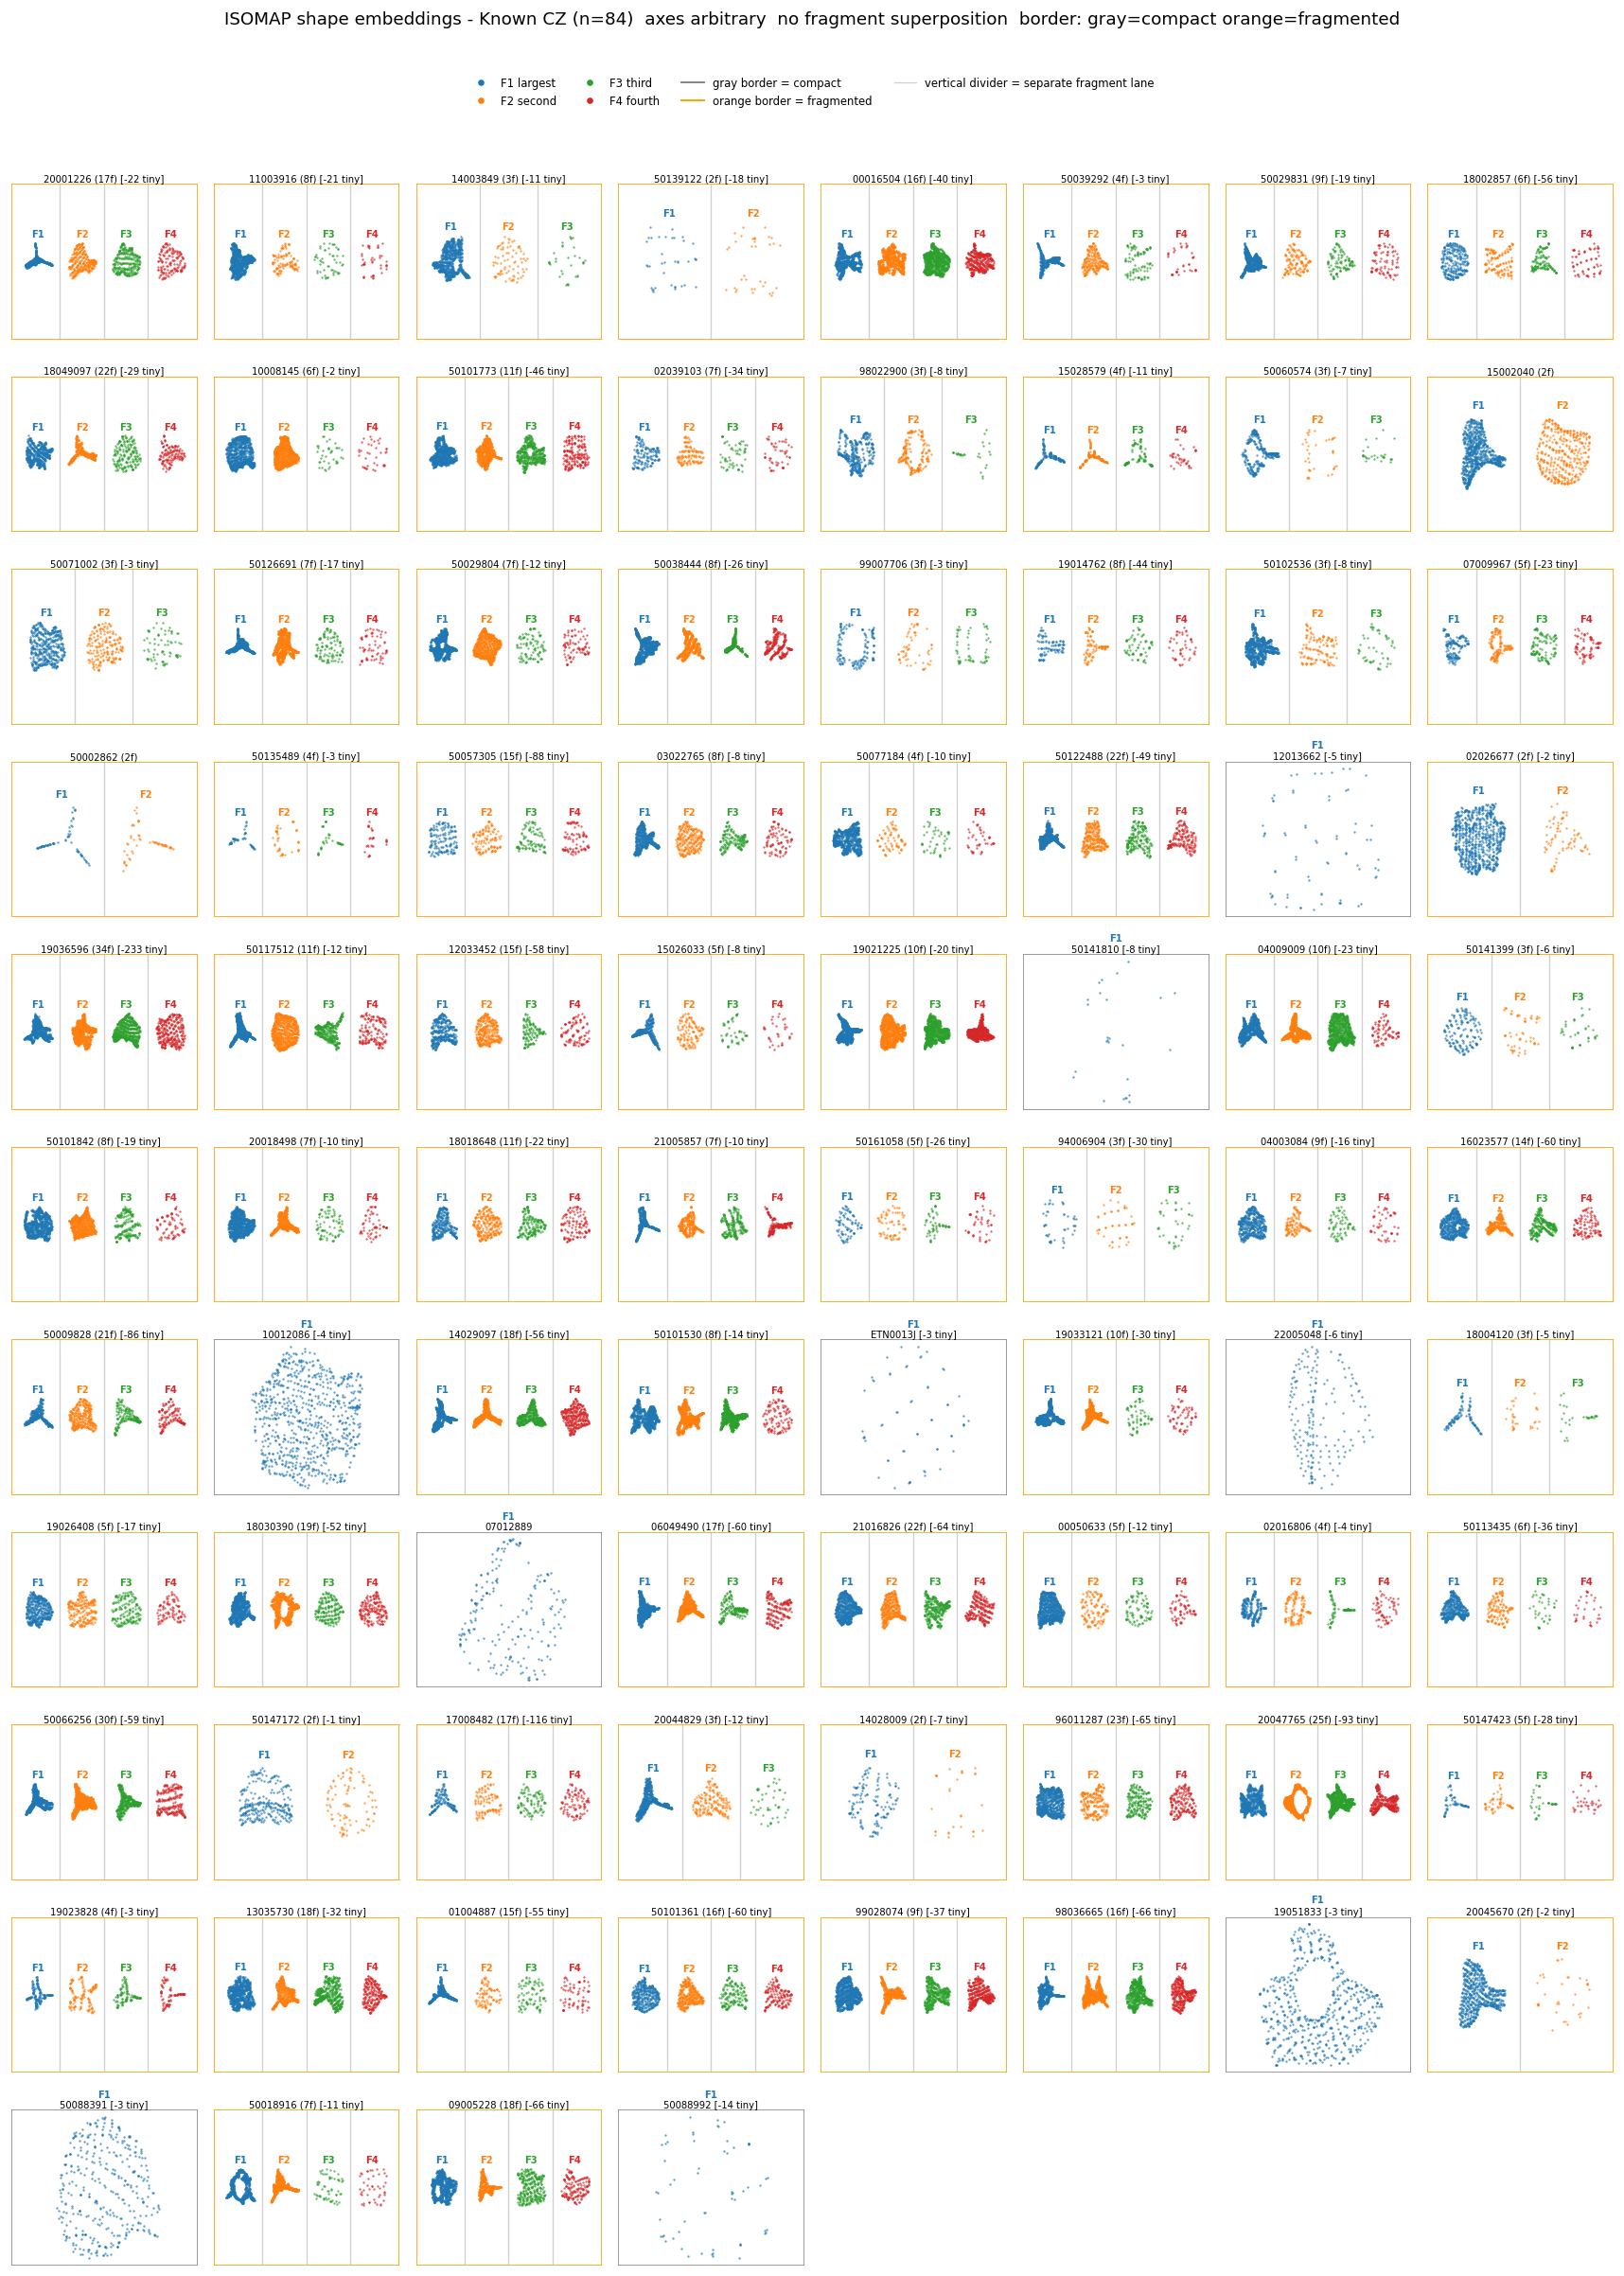

In [ ]:
FRAG_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
LANE_HALF_WIDTH = 0.32
LANE_HALF_HEIGHT = 0.42

def _fit_embedding_to_lane(emb, x_center, half_width=LANE_HALF_WIDTH, half_height=LANE_HALF_HEIGHT):
    emb = np.asarray(emb, dtype=float)
    emb = emb - emb.mean(axis=0, keepdims=True)
    maxabs_x = np.max(np.abs(emb[:, 0])) if len(emb) else 1.0
    maxabs_y = np.max(np.abs(emb[:, 1])) if len(emb) else 1.0
    sx = half_width / max(maxabs_x, 1e-9)
    sy = half_height / max(maxabs_y, 1e-9)
    emb2 = emb.copy()
    emb2[:, 0] = emb2[:, 0] * sx + x_center
    emb2[:, 1] = emb2[:, 1] * sy
    return emb2

def _plot_isomap_cell(ax, analysis):
    shown = min(len(analysis.embeddings), MAX_PLOT_FRAGMENTS)
    if shown == 0:
        ax.text(0.5, 0.5, "no emb", ha="center", va="center", fontsize=6, transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        return
    centers = [0.0] if shown == 1 else np.linspace(-(shown - 1) / 2, (shown - 1) / 2, shown)
    for fi, (emb, count, xoff) in enumerate(zip(analysis.embeddings[:shown], analysis.vertex_counts[:shown], centers)):
        color = FRAG_COLORS[fi % len(FRAG_COLORS)]
        if emb is not None and len(emb) > 0:
            emb_lane = _fit_embedding_to_lane(emb, xoff)
            ax.scatter(emb_lane[:, 0], emb_lane[:, 1], s=2, c=[color], alpha=0.7, linewidths=0)
            ax.text(xoff, 0.52, f"F{fi+1}", color=color, fontsize=6, fontweight='bold',
                    ha="center", va="bottom",
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.2))
        else:
            ax.scatter([xoff], [0], marker="x", s=20, c=[color], linewidths=1)
            ax.text(xoff, 0.52, f"F{fi+1}", color=color, fontsize=6, fontweight='bold',
                    ha="center", va="bottom",
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.2))
    if shown > 1:
        mids = (centers[:-1] + centers[1:]) / 2
        for mid in mids:
            ax.axvline(mid, color="#d0d0d0", lw=0.8, zorder=0)
    n   = analysis.n_fragments
    pid = analysis.key.split("/")[1]
    suffix = f" ({n}f)" if n > 1 else ""
    if analysis.dropped_fragments > 0:
        suffix += f" [-{analysis.dropped_fragments} tiny]"
    ax.set_title(f"{pid}{suffix}", fontsize=6, pad=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(min(centers) - 0.6, max(centers) + 0.6)
    # set_ylim removed: with adjustable="datalim" it was ignored anyway (caused a matplotlib warning)
    try:
        ax.set_aspect("equal", adjustable="datalim")
    except Exception:
        pass
    bc = "orange" if not analysis.is_compact else "#888888"
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color(bc)


if not analyses:
    print("No analyses available - check scan.")
else:
    ikeys = list(analyses.keys())
    ncols = 8
    nrows = max(1, int(np.ceil(len(ikeys) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.8, nrows*1.8), squeeze=False)
    fig.suptitle(
        f"ISOMAP shape embeddings - Known CZ (n={len(ikeys)})  axes arbitrary  no fragment superposition  border: gray=compact orange=fragmented",
        fontsize=11, y=1.01
    )
    axes_flat = axes.ravel()
    for ax in axes_flat:
        ax.axis("off")
    for ax, key in zip(axes_flat, ikeys):
        ax.axis("on")
        try:
            _plot_isomap_cell(ax, analyses[key])
        except Exception as e:
            ax.set_title(key.split("/")[1], fontsize=6)
            print(f"  plot failed {key}: {e}")
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[0], markersize=5, label='F1 largest'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[1], markersize=5, label='F2 second'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[2], markersize=5, label='F3 third'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FRAG_COLORS[3], markersize=5, label='F4 fourth'),
        plt.Line2D([0], [0], color='#888888', lw=1.2, label='gray border = compact'),
        plt.Line2D([0], [0], color='orange', lw=1.2, label='orange border = fragmented'),
        plt.Line2D([0], [0], color='#d0d0d0', lw=0.8, label='vertical divider = separate fragment lane'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.985),
               ncol=4, fontsize=7, frameon=False)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.savefig(OUT / "isomap_grid_known.png", bbox_inches="tight")
    plt.show()


### 1c - 3D fragment vs Isomap diagnostic

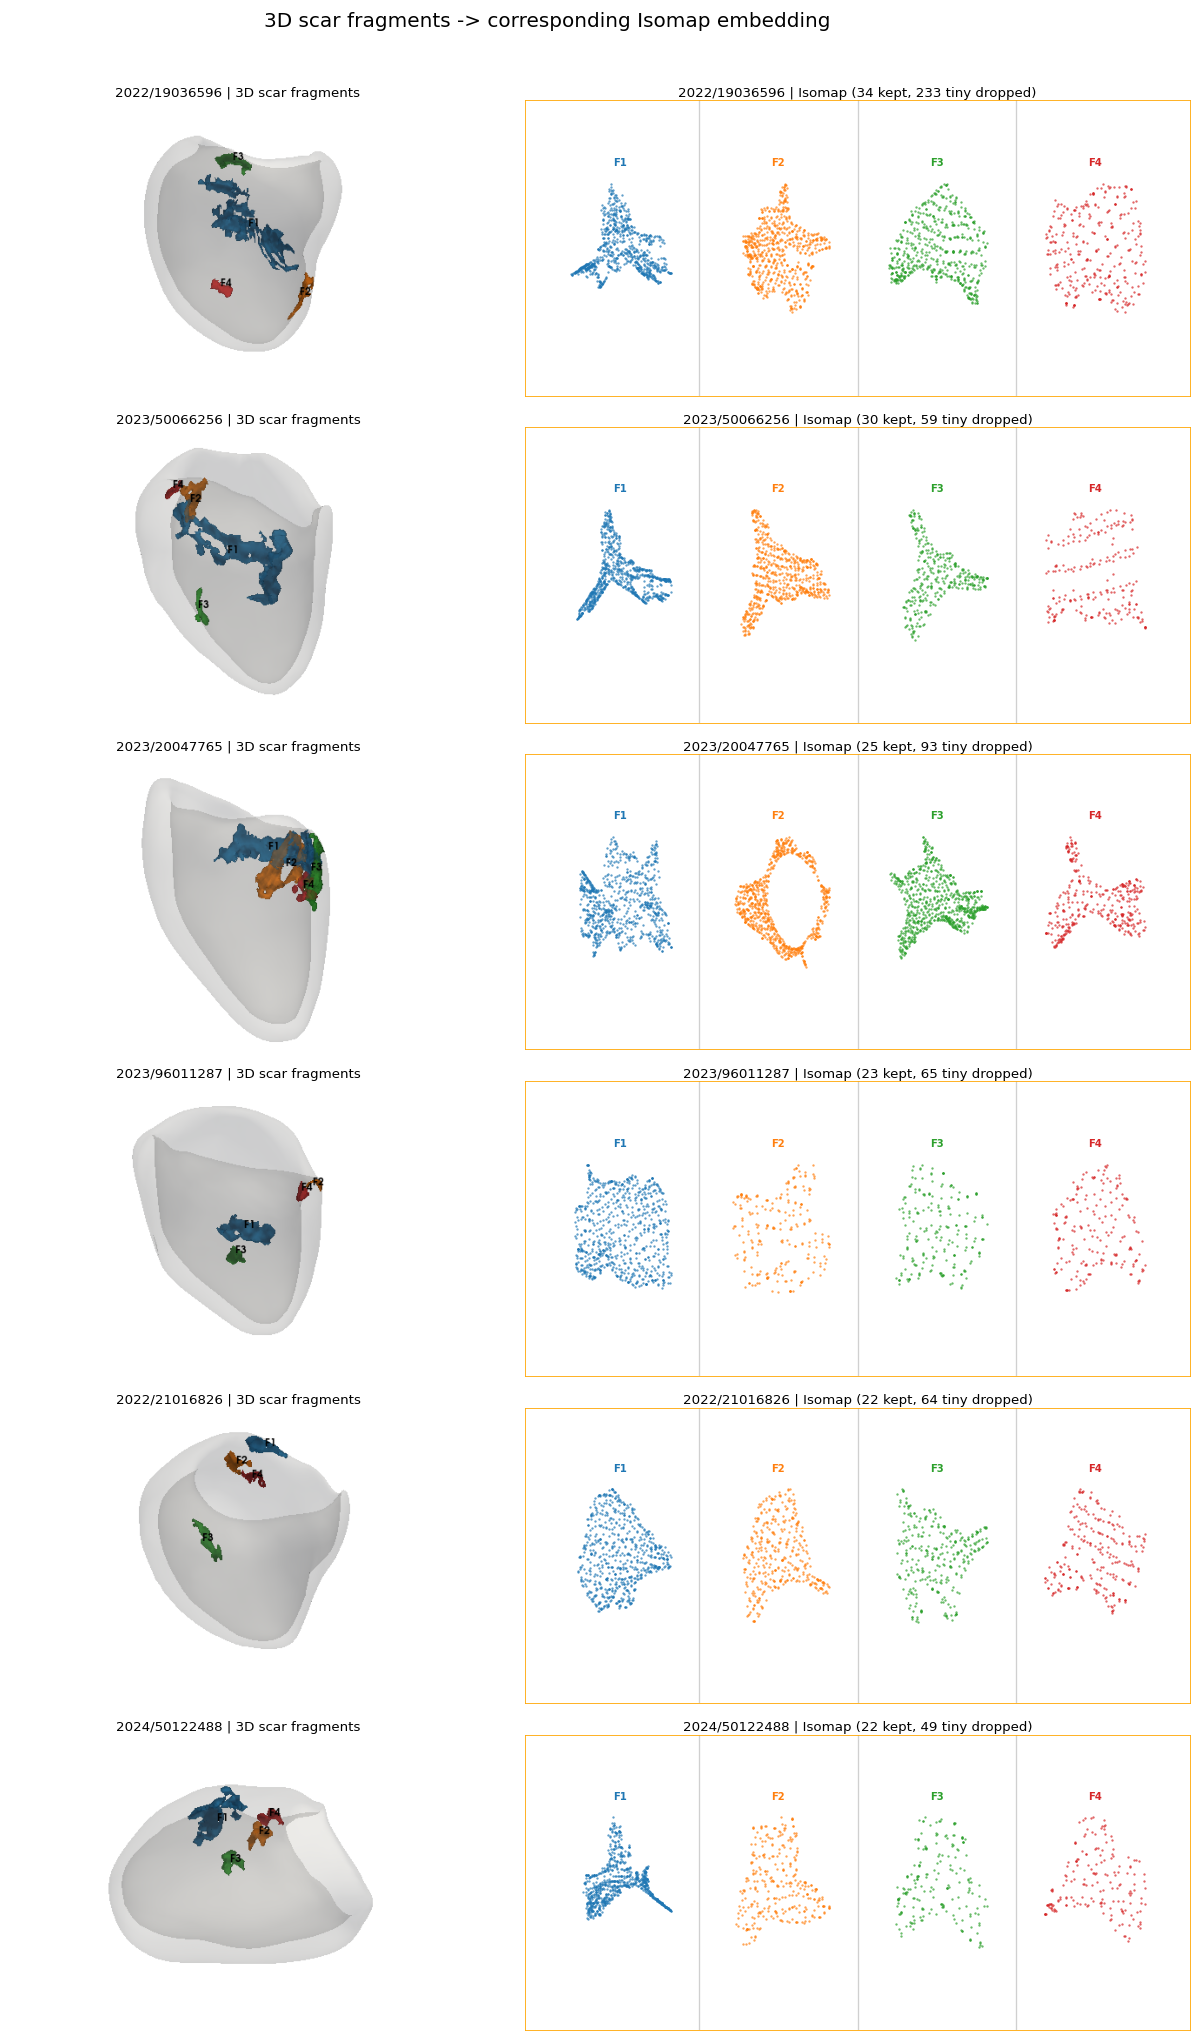

In [ ]:
ISOMAP_DIAG_CASES = 6

def _render_fragments_3d(analysis, case=None, title=''):
    shown = min(len(analysis.fragment_meshes), MAX_PLOT_FRAGMENTS)
    pl = pv.Plotter(off_screen=True, window_size=(520, 340))
    pl.set_background('white')
    if case is not None:
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='#cccccc', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
    for fi, frag in enumerate(analysis.fragment_meshes[:shown]):
        color = FRAG_COLORS[fi % len(FRAG_COLORS)]
        pl.add_mesh(frag, color=color, smooth_shading=True, opacity=0.95, show_scalar_bar=False)
        center = np.asarray(frag.center)
        pl.add_point_labels([center], [f'F{fi+1}'], font_size=12, point_size=0,
                            text_color='black', shape_opacity=0.0, always_visible=True)
    pl.view_isometric()
    pl.camera.zoom(1.25)
    img = pl.screenshot(None, return_img=True)
    pl.close()
    return img

def _plot_isomap_large(ax, analysis):
    _plot_isomap_cell(ax, analysis)
    ax.set_title(ax.get_title(), fontsize=8, pad=2)

if not analyses:
    print('No analyses available - run section 5a first.')
else:
    diag_cases = sorted(
        analyses.values(),
        key=lambda a: (a.n_fragments, a.dropped_fragments, sum(a.vertex_counts)),
        reverse=True,
    )[:ISOMAP_DIAG_CASES]
    nrows = len(diag_cases)
    fig, axes = plt.subplots(nrows, 2, figsize=(11, max(3, nrows * 2.8)))
    if nrows == 1:
        axes = np.array([axes])
    fig.suptitle('3D scar fragments -> corresponding Isomap embedding', fontsize=12, y=1.01)
    for row, analysis in enumerate(diag_cases):
        ax3d, axiso = axes[row]
        year, pid = analysis.key.split('/')
        case = next((c for c in known if c.patient_id == pid and str(c.year) == year), None)
        img = _render_fragments_3d(analysis, case=case, title=analysis.key)
        ax3d.imshow(img)
        ax3d.axis('off')
        ax3d.set_title(f"{analysis.key} | 3D scar fragments", fontsize=8, pad=2)
        _plot_isomap_large(axiso, analysis)
        axiso.set_title(
            f"{analysis.key} | Isomap ({analysis.n_fragments} kept, {analysis.dropped_fragments} tiny dropped)",
            fontsize=8,
            pad=2,
        )
    plt.tight_layout()
    plt.savefig(OUT / 'isomap_3d_vs_embedding_diagnostic.png', bbox_inches='tight')
    plt.show()


### 1d - Fragmentation summary

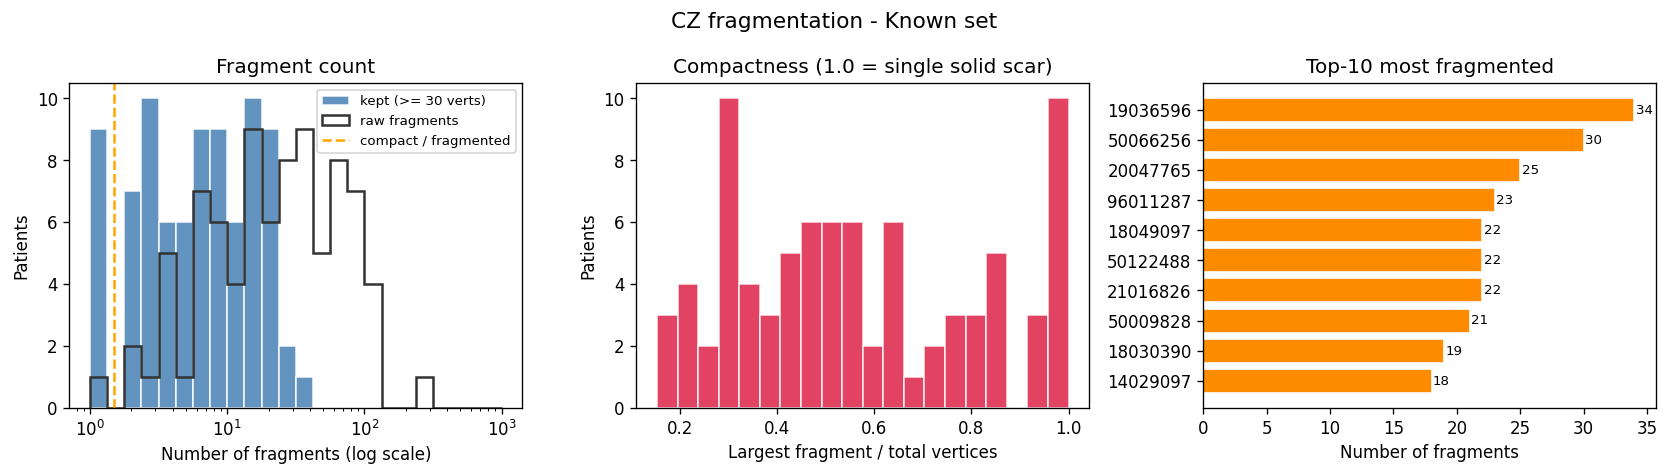

Median raw fragments         : 23
Median kept fragments        : 7
Max kept fragments           : 34
Median tiny fragments dropped: 17
Compact patients             : 9


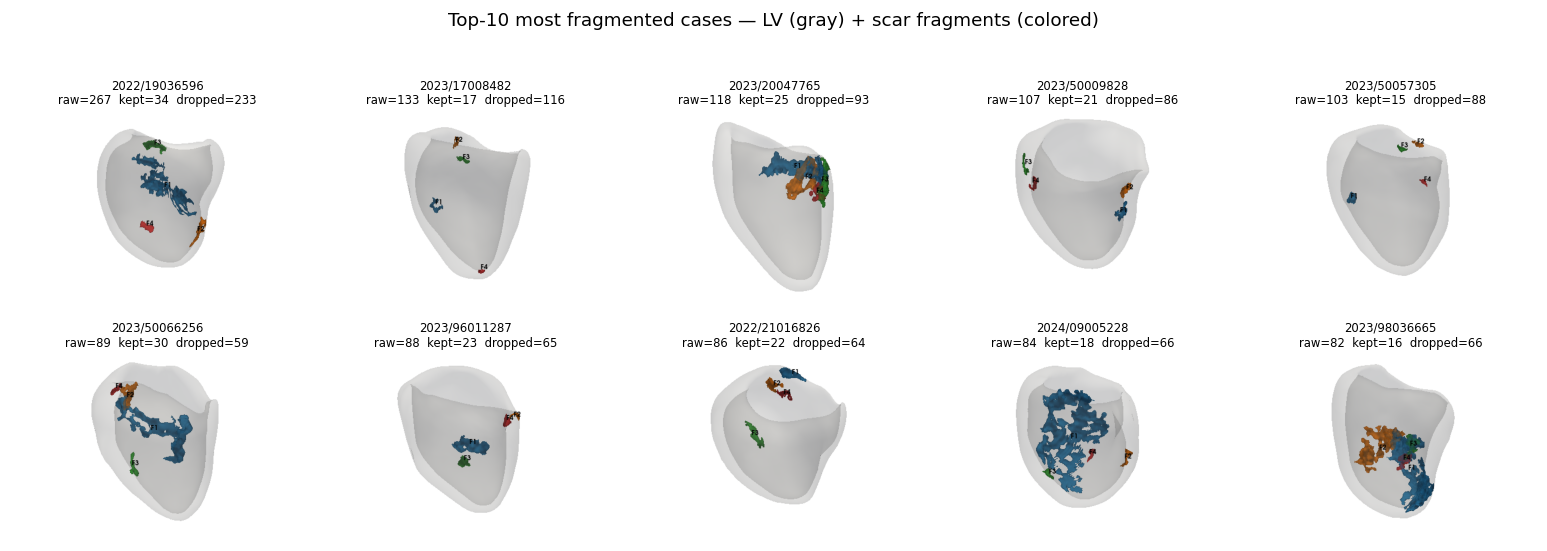

In [ ]:
if not analyses:
    print("No analyses.")
else:
    n_frags_all      = [a.n_fragments       for a in analyses.values()]
    raw_n_frags_all  = [a.raw_n_fragments   for a in analyses.values()]
    dropped_all      = [a.dropped_fragments for a in analyses.values()]
    largest_frac_all = [a.largest_fraction  for a in analyses.values()]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("CZ fragmentation - full cohort", fontsize=13)

    # --- Fragment count ---
    ax = axes[0]
    log_bins = np.logspace(0, np.ceil(np.log10(max(raw_n_frags_all) + 1)), 25)
    # kept: solid fill; raw: step outline so it never covers kept bars
    ax.hist(n_frags_all, bins=log_bins, color="steelblue", edgecolor="white",
            alpha=0.85, label=f"kept (>= {MIN_VERTS_FRAGMENT} verts)")
    ax.hist(raw_n_frags_all, bins=log_bins, histtype="step",
            color="#333333", linewidth=1.5, label="raw fragments")
    ax.set_xscale("log")
    ax.axvline(1.5, color="orange", lw=1.5, ls="--", label="compact / fragmented")
    ax.set_xlabel("Number of fragments (log scale)")
    ax.set_ylabel("Patients")
    ax.set_title("Fragment count")
    ax.legend(fontsize=8)

    # --- Compactness ---
    ax = axes[1]
    ax.hist(largest_frac_all, bins=20, color="crimson", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Largest fragment / total vertices")
    ax.set_ylabel("Patients")
    ax.set_title("Compactness (1.0 = single solid scar)")

    # --- Top-10 bar chart ---
    ax = axes[2]
    top10  = sorted(analyses.values(), key=lambda a: a.n_fragments, reverse=True)[:10]
    labels = [a.key.split("/")[1] for a in top10]
    counts = [a.n_fragments for a in top10]
    bars   = ax.barh(labels[::-1], counts[::-1], color="darkorange", edgecolor="white")
    ax.set_xlabel("Number of fragments")
    ax.set_title("Top-10 most fragmented")
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT / "fragmentation_summary.png", bbox_inches="tight")
    plt.show()

    print(f"Median raw fragments         : {int(np.median(raw_n_frags_all))}")
    print(f"Median kept fragments        : {int(np.median(n_frags_all))}")
    print(f"Max kept fragments           : {max(n_frags_all)}")
    print(f"Median tiny fragments dropped: {int(np.median(dropped_all))}")
    print(f"Compact patients             : {sum(1 for n in n_frags_all if n == 1)}")

    # --- 3D render grid: top fragmented cases ---
    TOP_FRAG_SHOW = 10
    top_frags = sorted(analyses.values(), key=lambda a: a.raw_n_fragments, reverse=True)[:TOP_FRAG_SHOW]
    ncols_g = 5
    nrows_g = int(np.ceil(TOP_FRAG_SHOW / ncols_g))
    fig2, axes2 = plt.subplots(nrows_g, ncols_g,
                               figsize=(ncols_g * 2.6, nrows_g * 2.4),
                               squeeze=False)
    fig2.suptitle(f"Top-{TOP_FRAG_SHOW} most fragmented cases — LV (gray) + scar fragments (colored)",
                  fontsize=11, y=1.01)
    for idx, analysis in enumerate(top_frags):
        ax = axes2[idx // ncols_g][idx % ncols_g]
        year, pid = analysis.key.split('/')
        case = next((c for c in known if c.patient_id == pid and str(c.year) == year), None)
        try:
            img = _render_fragments_3d(analysis, case=case)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha='center', va='center',
                    fontsize=6, transform=ax.transAxes, wrap=True)
        ax.axis('off')
        ax.set_title(
            f"{analysis.key}\n"
            f"raw={analysis.raw_n_fragments}  kept={analysis.n_fragments}  dropped={analysis.dropped_fragments}",
            fontsize=7, pad=2)
    for idx in range(TOP_FRAG_SHOW, nrows_g * ncols_g):
        axes2[idx // ncols_g][idx % ncols_g].axis('off')
    plt.tight_layout()
    plt.savefig(OUT / "top_fragmented_3d.png", bbox_inches="tight")
    plt.show()


XYZ-shape candidates (auto): 19


,key,year,patient_id,raw_n_fragments,n_fragments_kept,dropped_tiny,largest_fraction,f1_vertices,f1_peak_angles_deg,f1_arm_spacings_deg,selection_source
0,2021/15002040,2021,15002040,2,2,0,0.750,1242,"[132.5, 227.5, 357.5]","[95.0, 130.0, 135.0]",auto
1,2021/18018648,2021,18018648,33,11,22,0.255,334,"[77.5, 222.5, 337.5]","[145.0, 115.0, 100.0]",auto
2,2021/19033121,2021,19033121,40,10,30,0.711,2660,"[82.5, 192.5, 347.5]","[110.0, 155.0, 95.0]",auto
3,2021/20045670,2021,20045670,4,2,2,0.949,668,"[137.5, 212.5, 352.5]","[75.0, 140.0, 145.0]",auto
4,2022/11003916,2022,11003916,29,8,21,0.764,1144,"[7.5, 127.5, 242.5]","[120.0, 115.0, 125.0]",auto
5,2022/19036596,2022,19036596,267,34,233,0.474,3688,"[117.5, 197.5, 357.5]","[80.0, 160.0, 120.0]",auto
6,2022/50018916,2022,50018916,18,7,11,0.511,2252,"[87.5, 192.5, 337.5]","[105.0, 145.0, 110.0]",auto
7,2022/50029831,2022,50029831,28,9,19,0.852,3132,"[132.5, 217.5, 347.5]","[85.0, 130.0, 145.0]",auto
8,2022/50038444,2022,50038444,34,8,26,0.507,1578,"[2.5, 137.5, 227.5]","[135.0, 90.0, 135.0]",auto
9,2023/00050633,2023,00050633,17,5,12,0.689,772,"[132.5, 212.5, 347.5]","[80.0, 135.0, 145.0]",auto


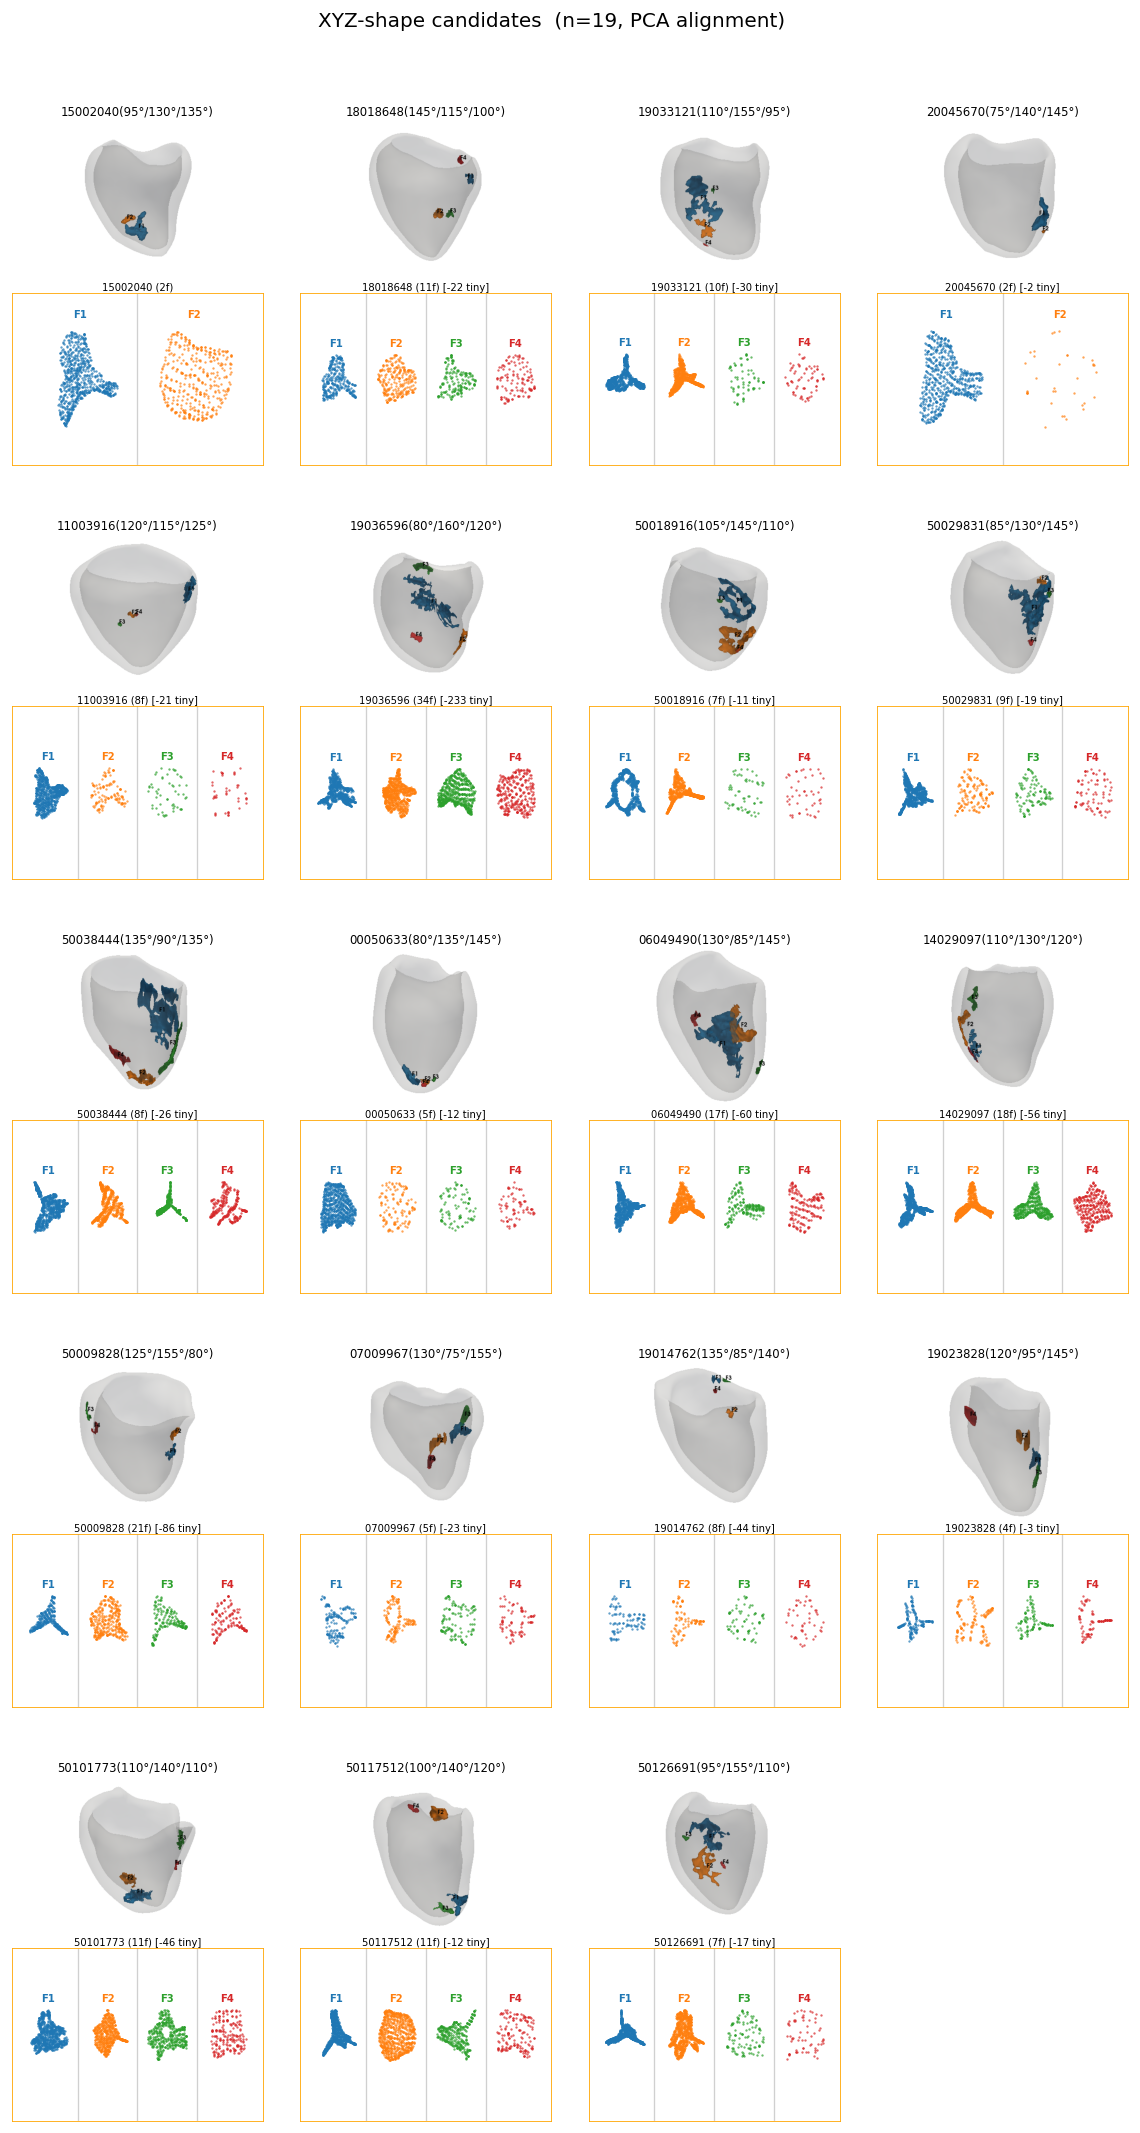

In [ ]:
XYZ_SHAPE_KEYS = [
    # Optional manual override after visual review, e.g.:
    # '2024/12345678',
]

XYZ_N_BINS        = 72
XYZ_SMOOTH_BINS   = 5
XYZ_MIN_PEAK_PROM = 0.07   # was 0.10 – lower to catch shallower arms
XYZ_MIN_PEAK_RADIUS = 0.30  # was 0.45 – accept more modest arm extent
XYZ_ARM_SPACING_DEG = 120
XYZ_ARM_TOL_DEG   = 45    # was 35 – allow more variation in arm spacing

def _f1_xyz_signature(analysis, n_bins=XYZ_N_BINS):
    emb = analysis.embeddings[0] if analysis.embeddings else None
    if emb is None or len(emb) < 30:
        return None
    pts = np.asarray(emb, dtype=float)
    pts = pts - pts.mean(axis=0, keepdims=True)
    radii  = np.linalg.norm(pts, axis=1)
    angles = np.arctan2(pts[:, 1], pts[:, 0])
    bins   = np.linspace(-np.pi, np.pi, n_bins + 1)
    mids   = 0.5 * (bins[:-1] + bins[1:])
    idx    = np.clip(np.digitize(angles, bins) - 1, 0, n_bins - 1)

    radial_env = np.zeros(n_bins, dtype=float)
    for bi, ri in zip(idx, radii):
        radial_env[bi] = max(radial_env[bi], ri)

    smooth_env = uniform_filter1d(radial_env, size=XYZ_SMOOTH_BINS, mode='wrap')
    peaks, props = find_peaks(
        smooth_env,
        prominence=XYZ_MIN_PEAK_PROM,
        distance=max(4, n_bins // 6),
    )
    peak_angles = (np.degrees(mids[peaks]) + 360) % 360
    peak_radii  = smooth_env[peaks]
    keep = peak_radii >= XYZ_MIN_PEAK_RADIUS
    peak_angles = np.sort(peak_angles[keep])
    peak_radii  = peak_radii[keep]

    is_xyz = False
    arm_spacings = np.array([])
    if len(peak_angles) == 3:
        arm_spacings = np.diff(np.r_[peak_angles, peak_angles[0] + 360])
        is_xyz = np.all(np.abs(arm_spacings - XYZ_ARM_SPACING_DEG) <= XYZ_ARM_TOL_DEG)

    return {
        'is_xyz': bool(is_xyz),
        'n_peaks': int(len(peak_angles)),
        'peak_angles_deg': np.round(peak_angles, 1).tolist(),
        'peak_radii': np.round(peak_radii, 3).tolist(),
        'arm_spacings_deg': np.round(arm_spacings, 1).tolist(),
    }


xyz_auto_rows = []
for analysis in analyses.values():
    sig = _f1_xyz_signature(analysis)
    if sig is None or not sig['is_xyz']:
        continue
    year, pid = analysis.key.split('/')
    xyz_auto_rows.append({
        'key': analysis.key,
        'year': int(year),
        'patient_id': pid,
        'raw_n_fragments': analysis.raw_n_fragments,
        'n_fragments_kept': analysis.n_fragments,
        'dropped_tiny': analysis.dropped_fragments,
        'largest_fraction': round(float(analysis.largest_fraction), 3),
        'f1_vertices': int(analysis.vertex_counts[0]) if analysis.vertex_counts else 0,
        'f1_peak_angles_deg': sig['peak_angles_deg'],
        'f1_arm_spacings_deg': sig['arm_spacings_deg'],
        'selection_source': 'auto',
    })

xyz_auto_df = pd.DataFrame(xyz_auto_rows).sort_values(
    ['year', 'patient_id']
).reset_index(drop=True) if xyz_auto_rows else pd.DataFrame()

if XYZ_SHAPE_KEYS:
    xyz_selected_df = pd.DataFrame([
        row for row in xyz_auto_rows if row['key'] in XYZ_SHAPE_KEYS
    ]).sort_values(['year', 'patient_id']).reset_index(drop=True)
    missing_keys = [k for k in XYZ_SHAPE_KEYS if k not in set(xyz_selected_df.get('key', []))]
    if missing_keys:
        print('Manual keys not matched by current auto-heuristic:')
        for key in missing_keys:
            print('  ', key)
else:
    xyz_selected_df = xyz_auto_df.copy()

print(f"XYZ-shape candidates (auto): {len(xyz_auto_df)}")
display(xyz_selected_df)

# --- Grid view of XYZ candidates (report-friendly) ---
# Each cell: 3D render on top, ISOMAP embedding below
xyz_keys = list(xyz_selected_df['key']) if not xyz_selected_df.empty else []
if not xyz_keys:
    print("No XYZ candidates to plot.")
else:
    XYZ_NCOLS = 4
    nrows_xyz = int(np.ceil(len(xyz_keys) / XYZ_NCOLS))
    fig_xyz = plt.figure(figsize=(XYZ_NCOLS * 3.0, nrows_xyz * 3.8))
    fig_xyz.suptitle(
        f"XYZ-shape candidates  (n={len(xyz_keys)}, PCA alignment)",
        fontsize=12, y=0.975,
    )
    outer = fig_xyz.add_gridspec(
        nrows_xyz, XYZ_NCOLS,
        top=0.93, bottom=0.05,
        hspace=0.18, wspace=0.15,
    )
    for idx, key in enumerate(xyz_keys):
        row_o, col_o = divmod(idx, XYZ_NCOLS)
        inner = outer[row_o, col_o].subgridspec(2, 1, hspace=0.03, height_ratios=[1.0, 1.0])
        ax3d  = fig_xyz.add_subplot(inner[0])
        axiso = fig_xyz.add_subplot(inner[1])

        analysis = analyses[key]
        year, pid = key.split('/')
        case = next((c for c in known if c.patient_id == pid and str(c.year) == year), None)

        try:
            img = _render_fragments_3d(analysis, case=case)
            ax3d.imshow(img)
        except Exception as e:
            ax3d.text(0.5, 0.5, str(e), ha='center', va='center',
                      fontsize=6, transform=ax3d.transAxes, wrap=True)
        ax3d.axis('off')
        sig = _f1_xyz_signature(analysis)
        spacings_str = "/".join(f"{s:.0f}°" for s in sig['arm_spacings_deg']) if sig else "?"
        ax3d.set_title(f"{pid}({spacings_str})", fontsize=7, pad=2)

        try:
            _plot_isomap_cell(axiso, analysis)
        except Exception as e:
            axiso.text(0.5, 0.5, str(e), ha='center', va='center',
                       fontsize=6, transform=axiso.transAxes)
            axiso.axis('off')

    for idx in range(len(xyz_keys), nrows_xyz * XYZ_NCOLS):
        row_o, col_o = divmod(idx, XYZ_NCOLS)
        fig_xyz.add_subplot(outer[row_o, col_o]).axis('off')

    plt.savefig(OUT / "xyz_candidates.png", bbox_inches="tight")
    plt.show()